In [1]:
from desc import set_device
set_device("gpu")

import numpy as np
from desc.objectives import TrappedResonance
from desc.equilibrium import Equilibrium
import matplotlib.pyplot as plt

In [2]:
eq = Equilibrium.load("precise_QH_output.h5")[-1]

num_eta = 20
Ekin_frac = 3e-4

s_min = 0.35
s_max = 0.45
pp = -1
qq = 8
data = np.load("poincare_data_Bcrit_0.91.npz")
num_rho = 30
knots_per_transit = 40
num_quad = 20
num_transit = 5
num_well = 1
num_eta = 30

Bcrit = 1/data['lam'][()]

# rho grid matches TrappedResonance's internal np.linspace(0, 1, num_rho + 1)[1:]
rhos = np.linspace(0, 1, num_rho + 1)[1:]
s_prof = rhos**2

obj = TrappedResonance(
    eq, num_rho=num_rho, num_eta=num_eta, M=1, N=1,
    pitch_invs=np.array([Bcrit]),
    num_well=num_well, num_transit=num_transit,
    knots_per_transit=knots_per_transit, num_quad=num_quad, KE_frac=Ekin_frac,
)
obj.build()
val = obj.compute(eq.params_dict)

Precomputing transforms


In [3]:
np.savez("desc_debug.npz", val=val)
val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
valid = np.isfinite(val['Delta_s'][0,0,:])
Delta_s = val['Delta_s'][0,0,valid]
s_res = val['s_res'][0,0,valid]
p_arr = val['p_arr'][valid]
q_arr = val['q_arr'][valid]
Omega = val['Omega'][:,0,0]
res_weight = val['res_weight'][:,0,0,valid]

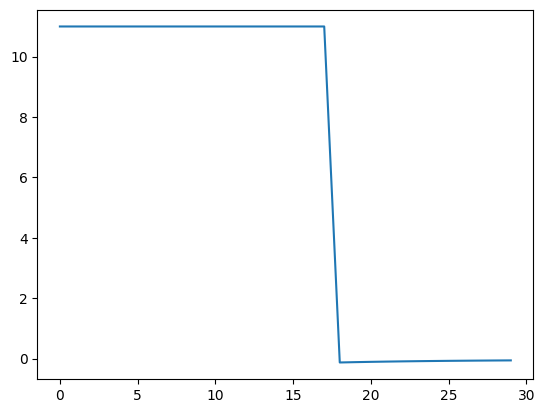

In [4]:
plt.figure()
plt.plot(Omega)

## Resonance is shifted by 0.0065 from firm3d location

<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_398593/455864915.py:13: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta$')


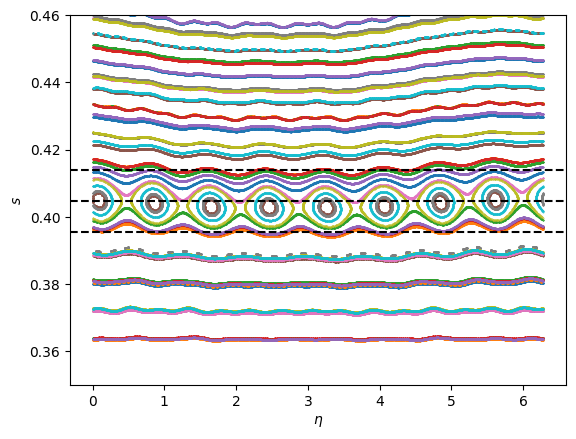

In [5]:
s_poinc = data['s_all']
etas_poinc = np.mod(data['etas_all'], 2*np.pi)

sshift = - 0.0065

plt.figure()
for i in range(len(s_poinc)):
    plt.scatter(etas_poinc[i],s_poinc[i],s=0.1)
plt.ylim(s_min,s_max+0.01)
plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] + sshift, color='k', linestyle='--')
plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] + 0.5*Delta_s[(p_arr == pp) & (q_arr == qq)] + sshift, color='k', linestyle='--')
plt.axhline(s_res[(p_arr == pp) & (q_arr == qq)] - 0.5*Delta_s[(p_arr == pp) & (q_arr == qq)] + sshift, color='k', linestyle='--')
plt.xlabel('$\eta$')
plt.ylabel('$s$')
plt.show()